[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\koush\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\koush\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\koush\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


✅ Model Accuracy: 0.52

🔹 Classification Report:
               precision    recall  f1-score   support

    Negative       0.56      0.60      0.58       111
    Positive       0.46      0.42      0.44        89

    accuracy                           0.52       200
   macro avg       0.51      0.51      0.51       200
weighted avg       0.52      0.52      0.52       200


🔹 Confusion Matrix:
 [[67 44]
 [52 37]]


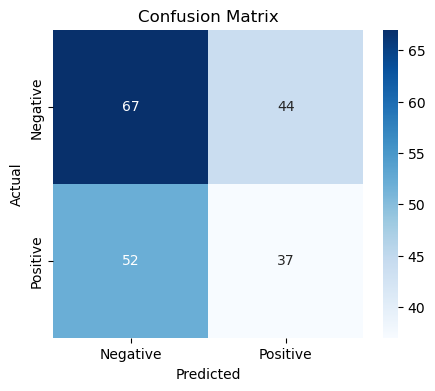

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import re
import string
import nltk
import seaborn as sns
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Ensure necessary nltk resources are downloaded
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

# Load the dataset
file_path = "reviews_dataset.csv"  # Update this if needed
df = pd.read_csv(file_path)

# Step 1: Data Preprocessing

# Function to clean and preprocess text
def preprocess_text(text):
    text = text.lower()  # Convert to lowercase
    text = re.sub(f"[{string.punctuation}]", "", text)  # Remove punctuation
    words = word_tokenize(text)  # Tokenize text
    words = [word for word in words if word not in stopwords.words('english')]  # Remove stopwords
    lemmatizer = WordNetLemmatizer()
    words = [lemmatizer.lemmatize(word) for word in words]  # Lemmatization
    return " ".join(words)

# Apply preprocessing
df["Cleaned Review"] = df["Review Text"].apply(preprocess_text)

# Step 2: Text Vectorization using TF-IDF
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df["Cleaned Review"])
y = df["Sentiment"].map({"positive": 1, "negative": 0})  # Convert sentiment to binary (1 = positive, 0 = negative)

# Step 3: Model Training

# Split into train-test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Logistic Regression model
model = LogisticRegression()
model.fit(X_train, y_train)

# Step 4: Model Evaluation

# Predictions
y_pred = model.predict(X_test)

# Accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"✅ Model Accuracy: {accuracy:.2f}")

# Precision, Recall, F1-Score
report = classification_report(y_test, y_pred, target_names=["Negative", "Positive"])
print("\n🔹 Classification Report:\n", report)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\n🔹 Confusion Matrix:\n", conf_matrix)

# Confusion Matrix Visualization
plt.figure(figsize=(5, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

🔹 Missing Values in Dataset:
Student Name    0
Roll Number     0
Study Hours     0
Attendance      0
Pass            0
dtype: int64


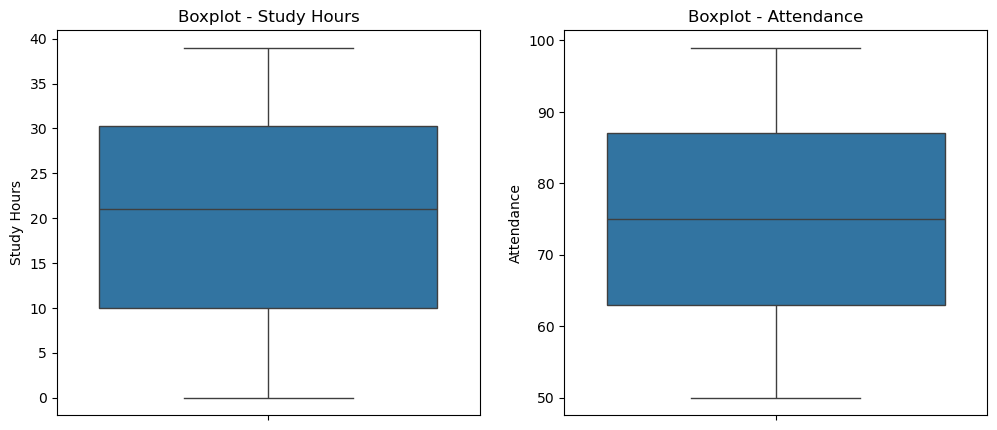

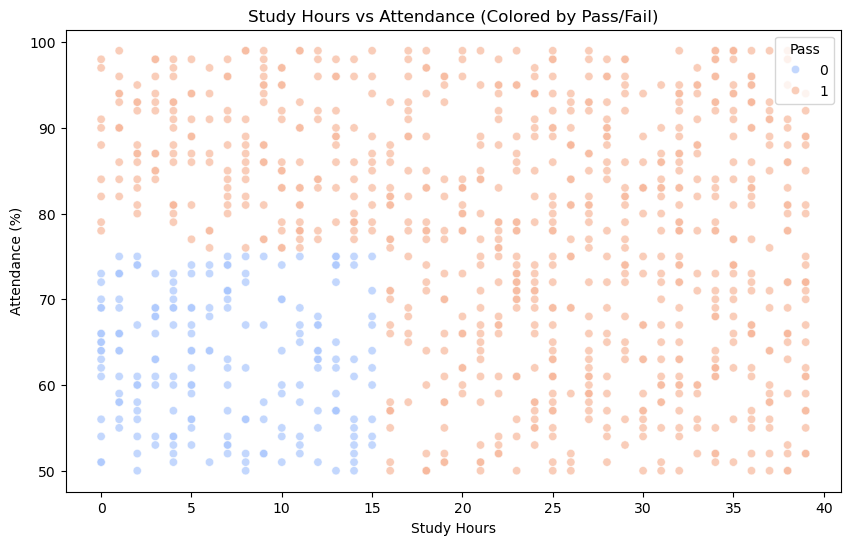

✅ Model Accuracy: 0.94

🔹 Confusion Matrix:
[[ 39   8]
 [  5 148]]


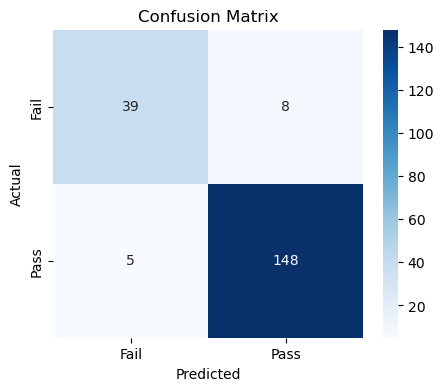

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split # type: ignore
from sklearn.linear_model import LogisticRegression # type: ignore
from sklearn.metrics import accuracy_score, confusion_matrix

# Load the dataset
file_path = "student_dataset.csv"  # Update this if needed
df = pd.read_csv(file_path)

# Step 1: Data Exploration

# Check for missing values
print("🔹 Missing Values in Dataset:")
print(df.isnull().sum())

# Identify outliers using boxplots
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y=df["Study Hours"])
plt.title("Boxplot - Study Hours")

plt.subplot(1, 2, 2)
sns.boxplot(y=df["Attendance"])
plt.title("Boxplot - Attendance")

plt.show()

# Plot relationship between Study Hours, Attendance, and Pass
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df["Study Hours"], y=df["Attendance"], hue=df["Pass"], palette="coolwarm", alpha=0.7)
plt.title("Study Hours vs Attendance (Colored by Pass/Fail)")
plt.xlabel("Study Hours")
plt.ylabel("Attendance (%)")
plt.show()

# Step 2: Model Training

# Define features and target variable
X = df[['Study Hours', 'Attendance']]
y = df['Pass']

# Split dataset into train-test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Logistic Regression model
model = LogisticRegression()
model.fit(X_train, y_train)

# Step 3: Model Evaluation

# Predictions
y_pred = model.predict(X_test)

# Accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"✅ Model Accuracy: {accuracy:.2f}")

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\n🔹 Confusion Matrix:")
print(conf_matrix)

# Confusion Matrix Visualization
plt.figure(figsize=(5, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=['Fail', 'Pass'], yticklabels=['Fail', 'Pass'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()